<a href="https://colab.research.google.com/github/sardar-ammad-143/Basic-Python/blob/main/Random%20forest%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Handle missing values
data.fillna(data.mean(), inplace=True)

# Remove outliers using Z-score (only for numerical columns)
from scipy.stats import zscore
numeric_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
data = data[(np.abs(zscore(data[numeric_columns])) < 3).all(axis=1)]

# View basic statistics to ensure cleaning worked
print(data.describe())



<ipython-input-20-0c656ac1f958>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(data.mean(), inplace=True)


               PM2.5           PM10             NO            NO2  \
count  637518.000000  637518.000000  637518.000000  637518.000000   
mean        0.289993       0.348893       0.176153       0.302170   
std         0.153990       0.151928       0.136183       0.148285   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.150101       0.220425       0.042363       0.174192   
50%         0.331582       0.439824       0.141010       0.329299   
75%         0.394136       0.439824       0.319611       0.406584   
max         0.775280       0.822660       0.600636       0.770133   

                 NOx            NH3             CO            SO2  \
count  637518.000000  637518.000000  637518.000000  637518.000000   
mean        0.215136       0.427476       0.283613       0.363031   
std         0.141647       0.145501       0.156255       0.144015   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.091112       0.3656

In [21]:
print(data.columns)



Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Trend', 'PM_Combined',
       'NOx_SO2'],
      dtype='object')


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Select columns for scaling
scaler = MinMaxScaler()
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

print(data.head())  # View the scaled dataset


       PM2.5      PM10        NO       NO2       NOx       NH3       CO  \
2   0.387267  0.350190  0.034603  0.304279  0.154876  0.185971  0.03876   
5   0.335221  0.287177  0.011424  0.223162  0.106113  0.213534  0.03876   
9   0.392108  0.326311  0.013079  0.300290  0.141893  0.159028  0.03876   
10  0.399371  0.325648  0.020530  0.263661  0.129319  0.157479  0.03876   
11  0.375163  0.298453  0.008113  0.283970  0.131875  0.137659  0.03876   

         SO2        O3   Benzene   Toluene    Xylene       AQI  AQI_Trend  \
2   0.429385  0.962931  0.028571  0.140014  0.042254  0.491731   0.370618   
5   0.328709  0.886262  0.028571  0.117537  0.000000  0.491731   0.370618   
9   0.413020  0.815236  0.032857  0.158511  0.023474  0.491731   0.434059   
10  0.451441  0.848803  0.028571  0.140014  0.018779  0.491731   0.434059   
11  0.411597  0.743724  0.028571  0.140951  0.000000  0.491731   0.434059   

    PM_Combined   NOx_SO2  
2      0.588327  0.035690  
5      0.496140  0.018720  
9 

In [23]:
# Calculate a rolling average of AQI (e.g., 7-day window)
data.loc[:, 'AQI_Trend'] = data['AQI'].rolling(window=7).mean()



In [24]:
# Example of interaction terms
#data.loc[:, 'PM_Combined'] = data['PM2.5'] + data['PM10']
#data.loc[:, 'NOx_SO2'] = data['NOx'] * data['SO2']



In [25]:
print(data.columns)



Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Trend', 'PM_Combined',
       'NOx_SO2'],
      dtype='object')


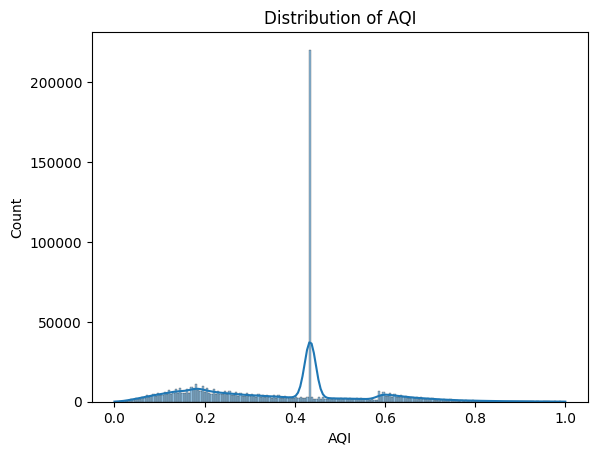

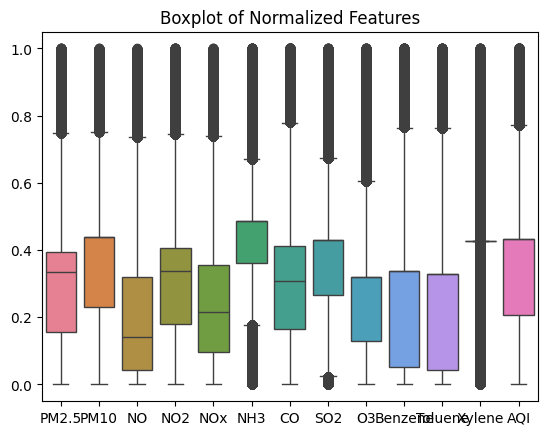

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of AQI after normalization
sns.histplot(data['AQI'], kde=True)
plt.title("Distribution of AQI")
plt.show()

# Boxplot to identify outliers
sns.boxplot(data=data[numeric_columns])
plt.title("Boxplot of Normalized Features")
plt.show()


In [27]:
data.to_csv("preprocessed_air_quality_data.csv", index=False)


Preprocessing Complete Next Step model training  using random forest


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming 'data' is your preprocessed DataFrame
X = data[['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Trend', 'PM_Combined', 'NOx_SO2']]
y = data['AQI']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')

Mean Absolute Error: 0.019782240071858477
Mean Squared Error: 0.0019829782823230046


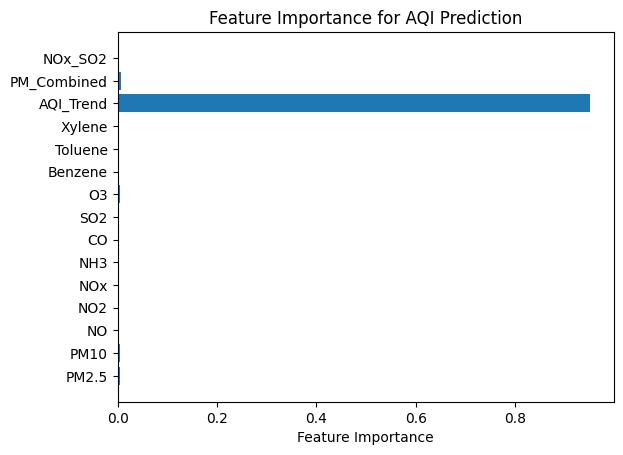

In [31]:
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_
plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for AQI Prediction')
plt.show()

In [33]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'random_forest_aqi_model.pkl')

['random_forest_aqi_model.pkl']

In [2]:
import joblib

# Load the trained model from the file
loaded_model = joblib.load('random_forest_aqi_model.pkl')

In [5]:
import pandas as pd

# Define the new data with the correct feature names
new_data = pd.DataFrame([[35.0, 50.0, 10.0, 20.0, 30.0, 5.0, 0.5, 0.02, 60.0, 0.1, 0.2, 0.3, 145, 40.0, 0.03]],
                        columns=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                                 'Benzene', 'Toluene', 'Xylene', 'AQI_Trend', 'PM_Combined', 'NOx_SO2'])

# Make predictions using the DataFrame
prediction = loaded_model.predict(new_data)
print(f'Predicted AQI: {prediction}')

Predicted AQI: [0.95613054]


In [14]:
import pandas as pd
import joblib  # Import joblib directly

# Load your trained model (make sure to replace 'your_model.pkl' with your actual model file)
loaded_model = joblib.load('/content/random_forest_aqi_model.pkl')

# Define new data with different values and include location
location = "Sadar"  # Example location
new_data = pd.DataFrame([[45.0, 60.0, 15.0, 25.0, 35.0, 7.0, 0.8, 0.03, 70.0,
                          0.2, 0.3, 0.4, 150, 50.0, 0.05]],
                        columns=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                                 'NH3', 'CO', 'SO2', 'O3', 'Benzene',
                                 'Toluene', 'Xylene', 'AQI_Trend',
                                 'PM_Combined', 'NOx_SO2'])

# Make predictions using the DataFrame
prediction = loaded_model.predict(new_data)

# Function to categorize the predicted AQI value
def categorize_aqi(predicted_value):
    # Scale the predicted value from 0 to 1 to 0 to 500
    scaled_aqi = predicted_value * 500

    # Determine the category based on the scaled AQI value
    if scaled_aqi <= 50:
        category = "Good"
    elif scaled_aqi <= 100:
        category = "Moderate"
    elif scaled_aqi <= 150:
        category = "Unhealthy for Sensitive Groups"
    elif scaled_aqi <= 200:
        category = "Unhealthy"
    elif scaled_aqi <= 300:
        category = "Very Unhealthy"
    else:
        category = "Hazardous"

    return scaled_aqi, category

# Categorize the predicted AQI
scaled_aqi, category = categorize_aqi(prediction[0])  # Assuming prediction returns an array

# Display the result including location
print(f'Location: {location}, Predicted AQI: {scaled_aqi:.2f}, Category: {category}')

Location: Sadar, Predicted AQI: 477.86, Category: Hazardous


In [19]:
import pandas as pd
import joblib  # Import joblib directly

# Load your trained model (make sure to replace 'your_model.pkl' with your actual model file)
loaded_model = joblib.load('/content/random_forest_aqi_model.pkl')

# Define new data for three different locations with different values
locations_data = {
    "Sadar": [10.0, 20.0, 5.0, 10.0, 15.0, 2.0, 0.2, 0.01, 30.0, 0.01, 0.02, 0.02, 0, 10.0, 0.01],
    "Bahria Town": [50.0, 70.0, 20.0, 30.0, 40.0, 10.0, 1.0, 0.05, 80.0, 0.15, 0.25, 0.35, 160, 60.0, 0.04],
    "Kahuta": [70.0, 90.0, 25.0, 35.0, 50.0, 15.0, 1.5, 0.1, 100.0, 0.2, 0.3, 0.4, 180, 80.0, 0.06]
}

# Function to categorize the predicted AQI value and assign a color
def categorize_aqi(predicted_value):
    # Scale the predicted value from 0 to 1 to 0 to 500
    scaled_aqi = predicted_value * 500

    # Determine the category and color based on the scaled AQI value
    if scaled_aqi <= 50:
        category = "Good"
        color = "Green"
    elif scaled_aqi <= 100:
        category = "Moderate"
        color = "Yellow"
    elif scaled_aqi <= 150:
        category = "Unhealthy for Sensitive Groups"
        color = "Orange"
    elif scaled_aqi <= 200:
        category = "Unhealthy"
        color = "Red"
    elif scaled_aqi <= 300:
        category = "Very Unhealthy"
        color = "Purple"
    else:
        category = "Hazardous"
        color = "Maroon"

    return scaled_aqi, category, color

# Iterate through each location and make predictions
for location, values in locations_data.items():
    new_data = pd.DataFrame([values], columns=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                                               'NH3', 'CO', 'SO2', 'O3', 'Benzene',
                                               'Toluene', 'Xylene', 'AQI_Trend',
                                               'PM_Combined', 'NOx_SO2'])

    # Make predictions using the DataFrame
    prediction = loaded_model.predict(new_data)

    # Categorize the predicted AQI
    scaled_aqi, category, color = categorize_aqi(prediction[0])  # Assuming prediction returns an array

    # Display the result including location and color
    print(f'Location: {location}, Predicted AQI: {scaled_aqi:.2f}, Category: {category}, Color: {color}')

Location: Sadar, Predicted AQI: 3.78, Category: Good, Color: Green
Location: Bahria Town, Predicted AQI: 477.35, Category: Hazardous, Color: Maroon
Location: Kahuta, Predicted AQI: 478.10, Category: Hazardous, Color: Maroon


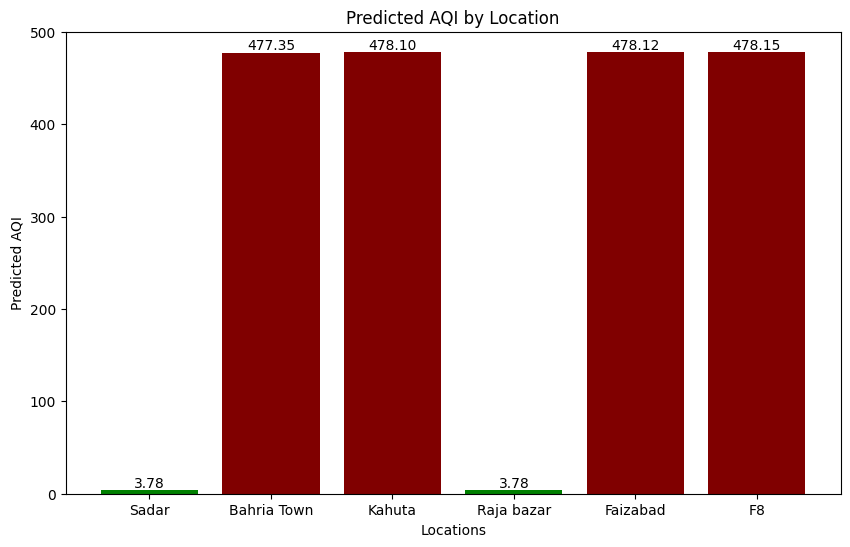

In [25]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load your trained model
loaded_model = joblib.load('/content/random_forest_aqi_model.pkl')

# Define new data for three different locations with different values
locations_data = {
    "Sadar": [10.0, 20.0, 5.0, 10.0, 15.0, 2.0, 0.2, 0.01, 30.0, 0.01, 0.02, 0.02, 0, 10.0, 0.01],
    "Bahria Town": [50.0, 70.0, 20.0, 30.0, 40.0, 10.0, 1.0, 0.05, 80.0, 0.15, 0.25, 0.35, 160, 60.0, 0.04],
    "Kahuta": [70.0, 90.0, 25.0, 35.0, 50.0, 15.0, 1.5, 0.1, 100.0, 0.2, 0.3, 0.4, 180, 80.0, 0.06],
    "Raja bazar": [10.0, 20.0, 5.0, 10.0, 15.0, 2.0, 0.2, 0.01, 30.0, 0.01, 0.02, 0.02, 0, 10.0, 0.01],
    "Faizabad": [35.0, 50.0, 15.0, 20.0, 25.0, 5.0, 0.5, 0.02, 60.0, 0.1, 0.15, 0.2, 80, 30.0, 0.02],
    "F8": [35.0, 50.0, 15.0, 25.0, 30.0, 5.0, 0.5, 0.03, 60.0, 0.02, 0.05, 0.05, 1.0, 35.0, 0.02],

}

# Function to categorize the predicted AQI value and assign a color
def categorize_aqi(predicted_value):
    scaled_aqi = predicted_value * 500
    if scaled_aqi <= 50:
        category = "Good"
        color = "Green"
    elif scaled_aqi <= 100:
        category = "Moderate"
        color = "Yellow"
    elif scaled_aqi <= 150:
        category = "Unhealthy for Sensitive Groups"
        color = "Orange"
    elif scaled_aqi <= 200:
        category = "Unhealthy"
        color = "Red"
    elif scaled_aqi <= 300:
        category = "Very Unhealthy"
        color = "Purple"
    else:
        category = "Hazardous"
        color = "Maroon"

    return scaled_aqi, category, color

# Prepare data for plotting
locations = []
predicted_aqi = []
colors = []

# Iterate through each location and make predictions
for location, values in locations_data.items():
    new_data = pd.DataFrame([values], columns=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                                               'NH3', 'CO', 'SO2', 'O3', 'Benzene',
                                               'Toluene', 'Xylene', 'AQI_Trend',
                                               'PM_Combined', 'NOx_SO2'])

    # Make predictions using the DataFrame
    prediction = loaded_model.predict(new_data)

    # Categorize the predicted AQI
    scaled_aqi, category, color = categorize_aqi(prediction[0])

    # Store the results for plotting
    locations.append(location)
    predicted_aqi.append(scaled_aqi)
    colors.append(color)

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(locations, predicted_aqi, color=colors)

# Add labels and title
plt.xlabel('Locations')
plt.ylabel('Predicted AQI')
plt.title('Predicted AQI by Location')
plt.ylim(0, 500)

# Add AQI value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

# Show the plot
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')